**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: Felipe de Jesús Rodríguez Mancera
*   MATRÍCULA: A01840985

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [ ]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.2 MB/s eta 0:00:00


In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy import stats
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [ ]:
compu_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MNA/TC5053 - Ciencia y analítica de datos/Ejercicios_tareas/computer_prices.csv')
compu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb            

In [ ]:
# Contar columnas numéricas y de texto
numeric_cols = compu_df.select_dtypes(include='number').shape[1]
text_cols = compu_df.select_dtypes(include=['object', 'string']).shape[1]

print(f"Columnas numéricas: {numeric_cols}")
print(f"Columnas de texto: {text_cols}")

Columnas numéricas: 15
Columnas de texto: 12


In [ ]:
valores_unicos = compu_df.nunique()
print("Cantidad de valores únicos por columna:")
print(valores_unicos)

Cantidad de valores únicos por columna:
device_type                2
brand                     10
model                  99036
release_year               8
os                         4
form_factor               10
cpu_brand                  3
cpu_model              26971
cpu_tier                   6
cpu_cores                 12
cpu_threads               25
gpu_brand                  4
gpu_model                 49
gpu_tier                   6
vram_gb                    8
ram_gb                    15
storage_type               4
storage_gb                 5
storage_drive_count        4
display_type               6
charger_watts              7
psu_watts                  9
wifi                       4
bluetooth                  5
weight_kg                 47
warranty_months            4
price                   3366
dtype: int64


In [ ]:
# Eliminar las variables solicitadas
compu_df = compu_df.drop(columns=['model', 'cpu_model'])

# Verificar que se eliminaron mostrando las primeras filas
print(compu_df.head())

  device_type     brand  release_year       os form_factor cpu_brand  \
0     Desktop   Samsung          2022  Windows         ATX     Intel   
1      Laptop   Samsung          2022  Windows  Mainstream     Intel   
2     Desktop    Lenovo          2024    macOS         SFF       AMD   
3     Desktop      Dell          2024  Windows         ATX       AMD   
4      Laptop  Gigabyte          2024    Linux      Gaming       AMD   

   cpu_tier  cpu_cores  cpu_threads gpu_brand  ... storage_gb  \
0         3         12           24    NVIDIA  ...       1024   
1         4         12           24    NVIDIA  ...        512   
2         2          8           16    NVIDIA  ...        512   
3         2          6           12       AMD  ...        512   
4         5         16           32    NVIDIA  ...        256   

   storage_drive_count  display_type  charger_watts psu_watts     wifi  \
0                    1           LED              0       750  Wi-Fi 6   
1                    1      

In [ ]:
compu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   release_year         100000 non-null  int64  
 3   os                   100000 non-null  object 
 4   form_factor          100000 non-null  object 
 5   cpu_brand            100000 non-null  object 
 6   cpu_tier             100000 non-null  int64  
 7   cpu_cores            100000 non-null  int64  
 8   cpu_threads          100000 non-null  int64  
 9   gpu_brand            100000 non-null  object 
 10  gpu_model            100000 non-null  object 
 11  gpu_tier             100000 non-null  int64  
 12  vram_gb              100000 non-null  int64  
 13  ram_gb               100000 non-null  int64  
 14  storage_type         100000 non-null  object 
 15  storage_gb        

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

In [ ]:
# ── 1. Duplicados y nulos ──────────────────────────────────────────────────────
print(f"Duplicados: {compu_df.duplicated().sum()}")
print(f"\nValores nulos:\n{compu_df.isnull().sum()}")


Duplicados: 0

Valores nulos:
device_type            0
brand                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64


In [ ]:
print("\nEstadísticas descriptivas - Variables Numéricas:")
print(compu_df.describe().round(2))


Estadísticas descriptivas - Variables Numéricas:
       release_year   cpu_tier  cpu_cores  cpu_threads   gpu_tier    vram_gb  \
count     100000.00  100000.00  100000.00    100000.00  100000.00  100000.00   
mean        2022.32       3.15      10.52        19.37       2.99       6.15   
std            2.03       1.37       5.04         9.72       1.46       3.96   
min         2018.00       1.00       4.00         4.00       1.00       0.00   
25%         2021.00       2.00       6.00        12.00       2.00       4.00   
50%         2023.00       3.00       8.00        16.00       3.00       6.00   
75%         2024.00       4.00      14.00        24.00       4.00       8.00   
max         2025.00       6.00      28.00        56.00       6.00      16.00   

          ram_gb  storage_gb  storage_drive_count  charger_watts  psu_watts  \
count  100000.00   100000.00            100000.00      100000.00  100000.00   
mean       39.71      903.94                 1.52          61.38     27

In [ ]:
# Estadísticas descriptivas de variables categóricas (texto)
print("\nEstadísticas descriptivas - Variables Categóricas:")
print(compu_df.describe(include=['object']))


Estadísticas descriptivas - Variables Categóricas:
       device_type   brand       os form_factor cpu_brand gpu_brand  \
count       100000  100000   100000      100000    100000    100000   
unique           2      10        4          10         3         4   
top         Laptop  Lenovo  Windows  Mainstream     Intel    NVIDIA   
freq         59844   15992    71817       17819     52774     54712   

               gpu_model storage_type display_type     wifi  
count             100000       100000       100000   100000  
unique                49            4            6        4  
top     Apple Integrated         NVMe          LED  Wi-Fi 6  
freq               18922        45059        32000    46149  


In [ ]:
print("\nTABLAS DE FRECUENCIA")
for col in columnas_categoricas:
    top10 = compu_df[col].value_counts().head(10)
    freq  = pd.DataFrame({
        "Frecuencia": top10,
        "Porcentaje": (top10 / len(compu_df) * 100).round(2)
    })
    print(f"\n── {col} ({compu_df[col].nunique()} únicos) ──")
    print(freq.to_string())



TABLAS DE FRECUENCIA

── device_type (2 únicos) ──
             Frecuencia  Porcentaje
device_type                        
Laptop            59844       59.84
Desktop           40156       40.16

── brand (10 únicos) ──
          Frecuencia  Porcentaje
brand                           
Lenovo         15992       15.99
HP             14114       14.11
Dell           14005       14.00
Apple          11915       11.92
ASUS           10159       10.16
Acer            9925        9.93
Samsung         8066        8.07
MSI             7891        7.89
Gigabyte        4900        4.90
Razer           3033        3.03

── os (4 únicos) ──
          Frecuencia  Porcentaje
os                              
Windows        71817       71.82
macOS          18207       18.21
Linux           6109        6.11
ChromeOS        3867        3.87

── form_factor (10 únicos) ──
             Frecuencia  Porcentaje
form_factor                        
Mainstream        17819       17.82
Gaming            16876  

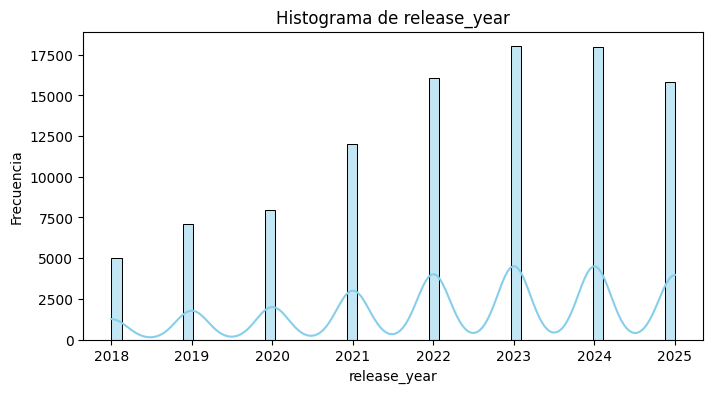

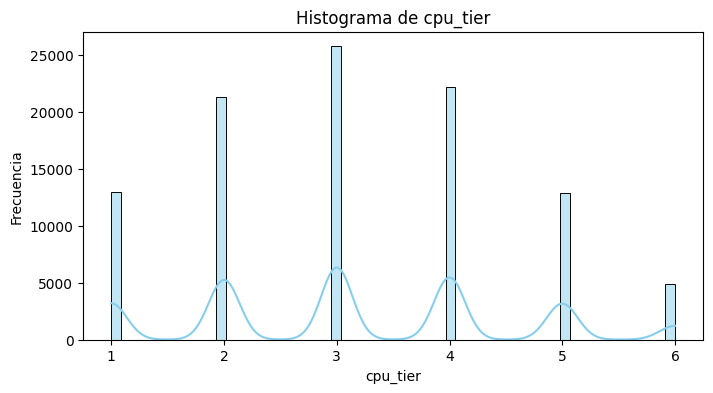

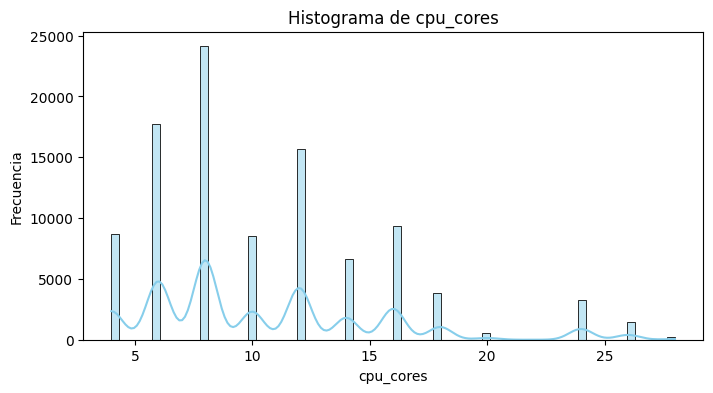

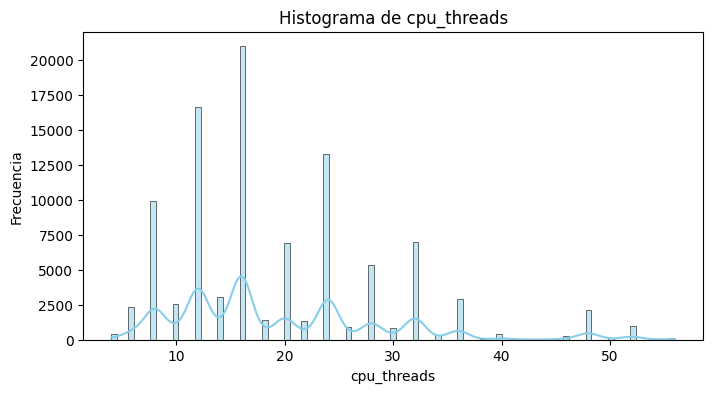

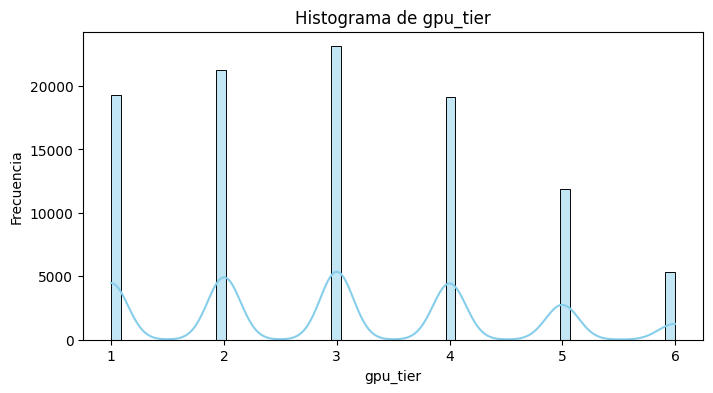

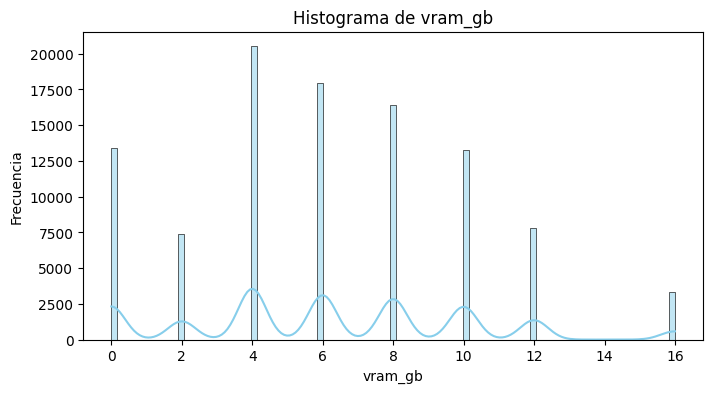

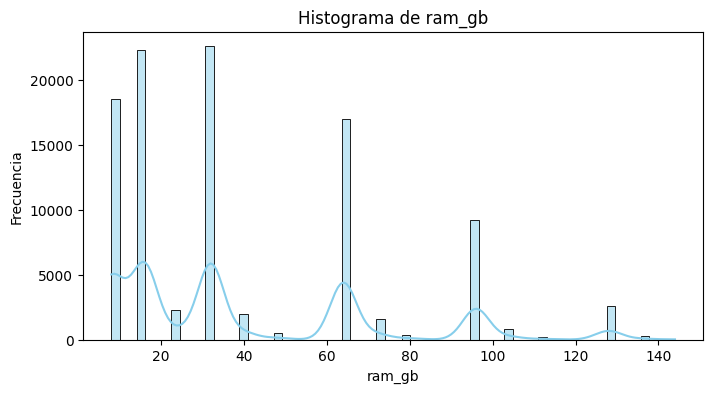

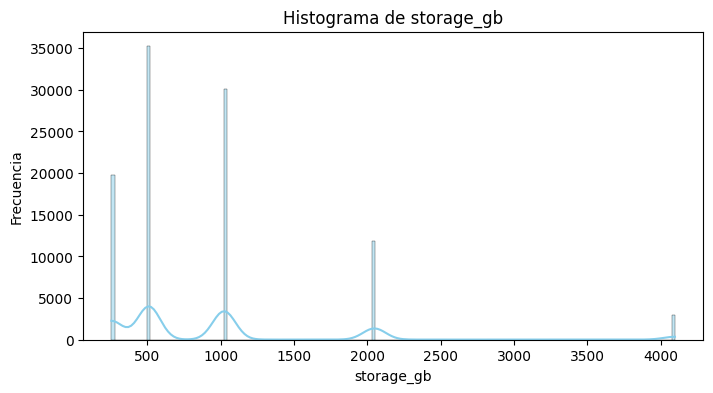

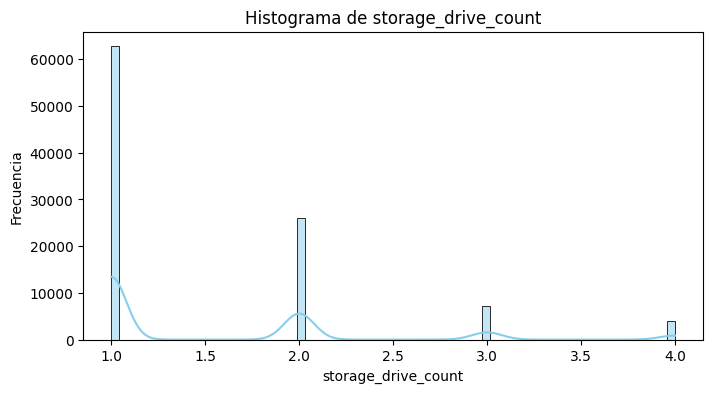

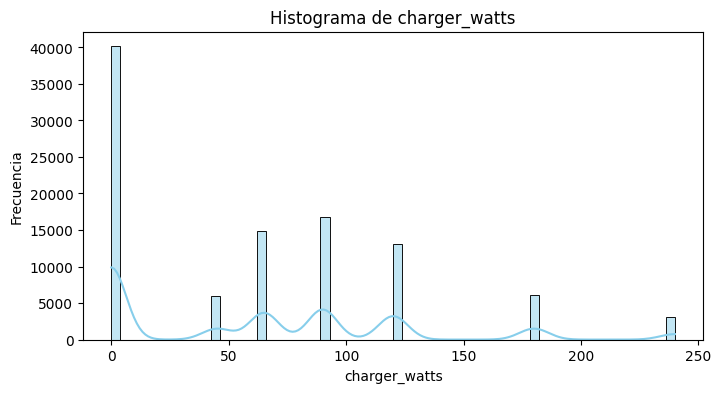

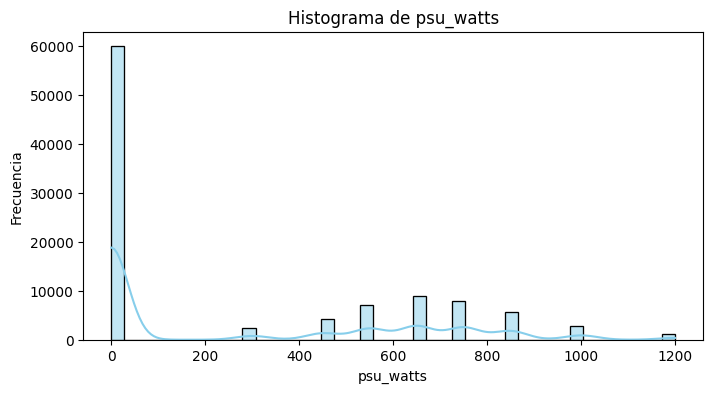

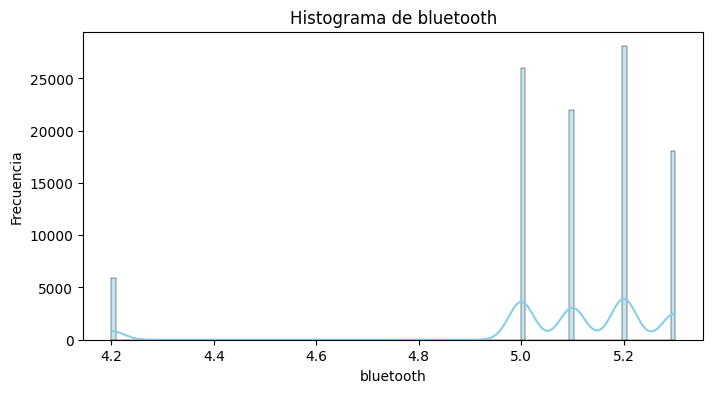

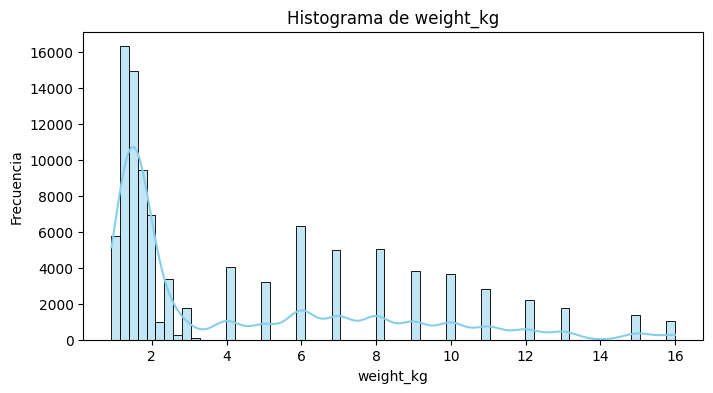

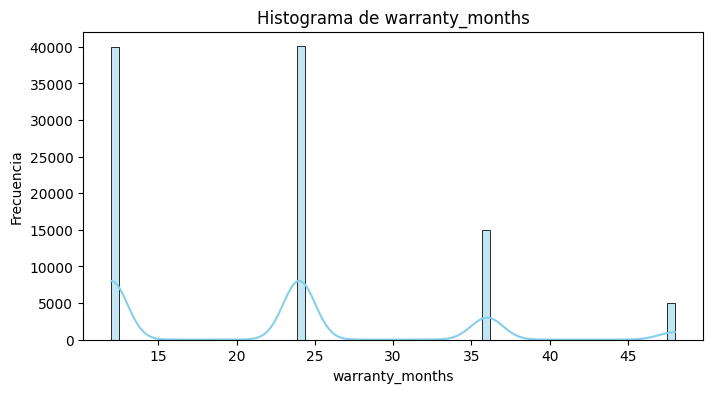

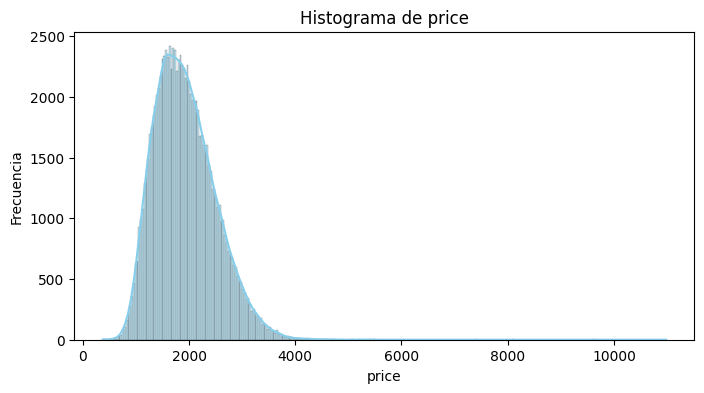

In [ ]:
# Histograma para variables numéricas
columnas_numericas = compu_df.select_dtypes(include=['int64', 'float64']).columns

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.histplot(compu_df[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

/tmp/ipykernel_1998/1143160511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


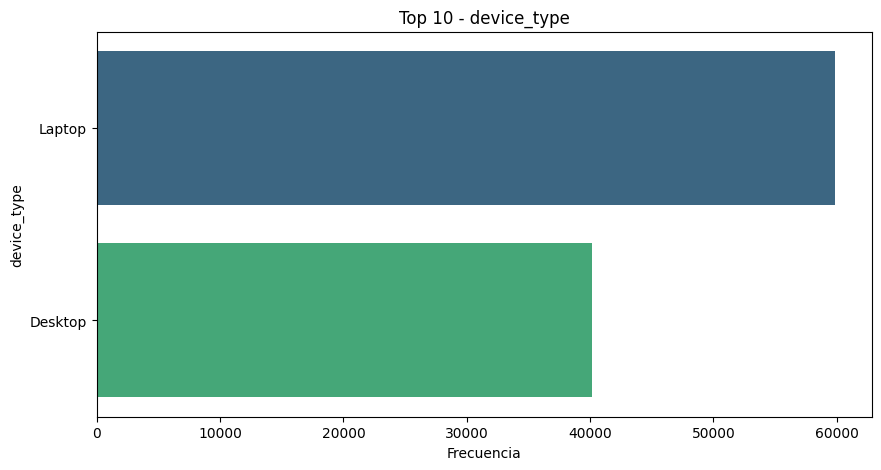

/tmp/ipykernel_1998/1143160511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


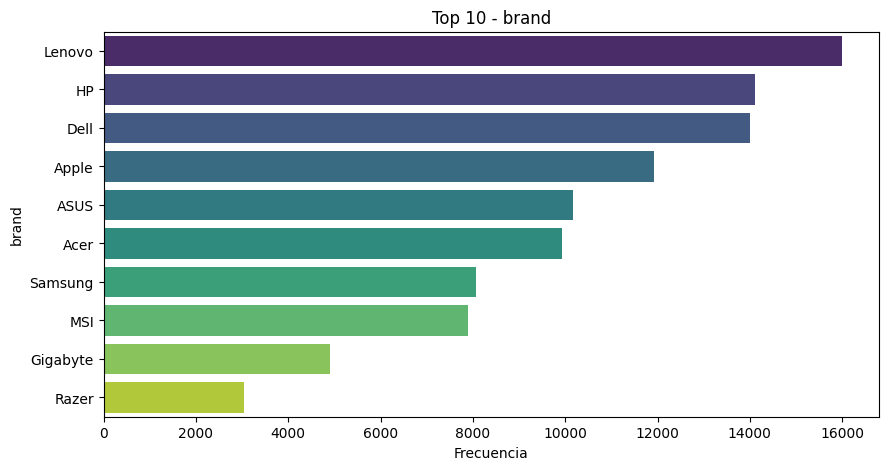

/tmp/ipykernel_1998/1143160511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


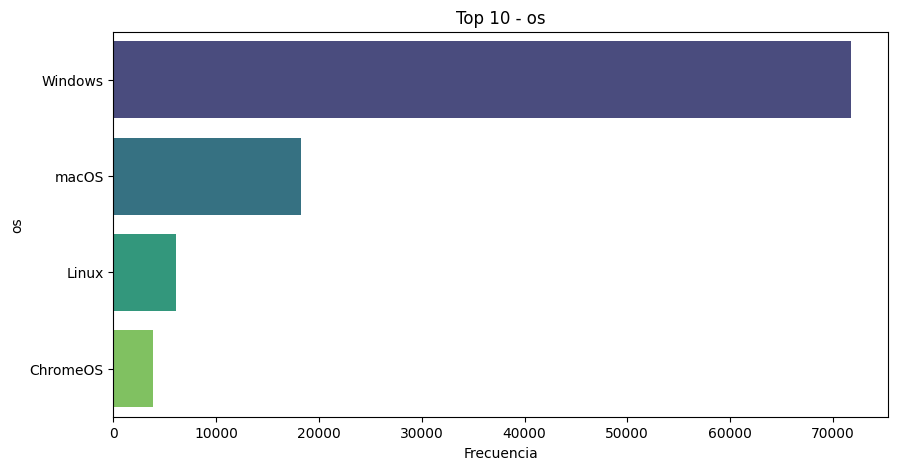

/tmp/ipykernel_1998/1143160511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


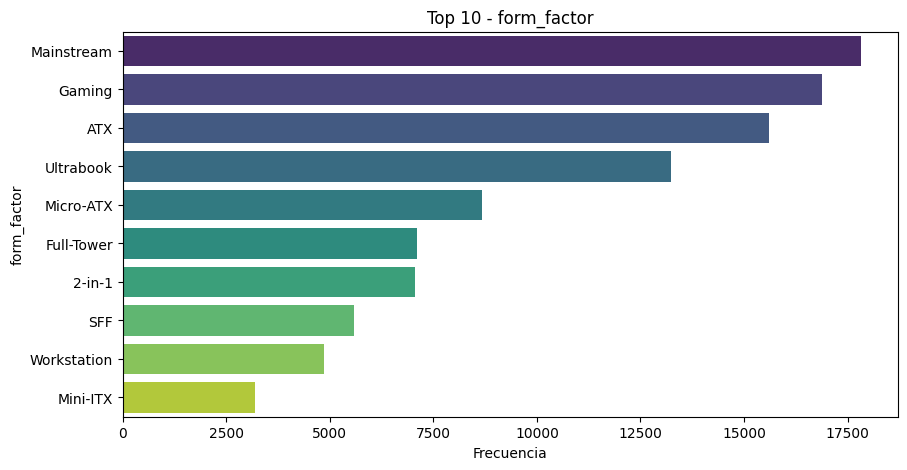

/tmp/ipykernel_1998/1143160511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


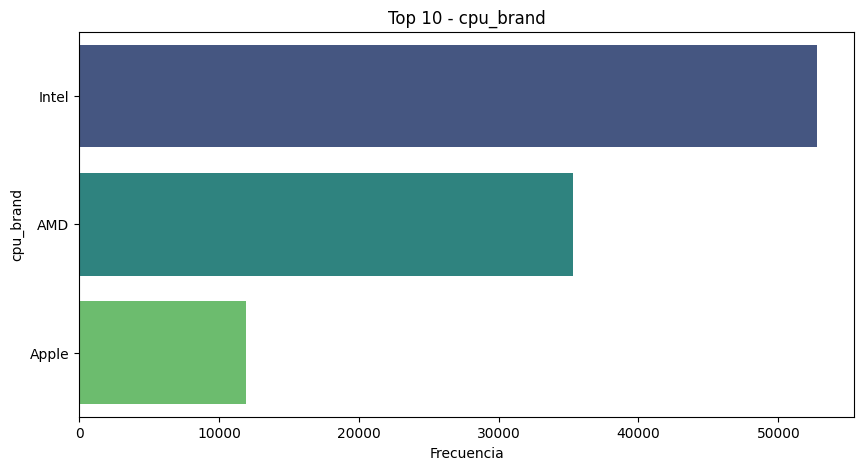

/tmp/ipykernel_1998/1143160511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


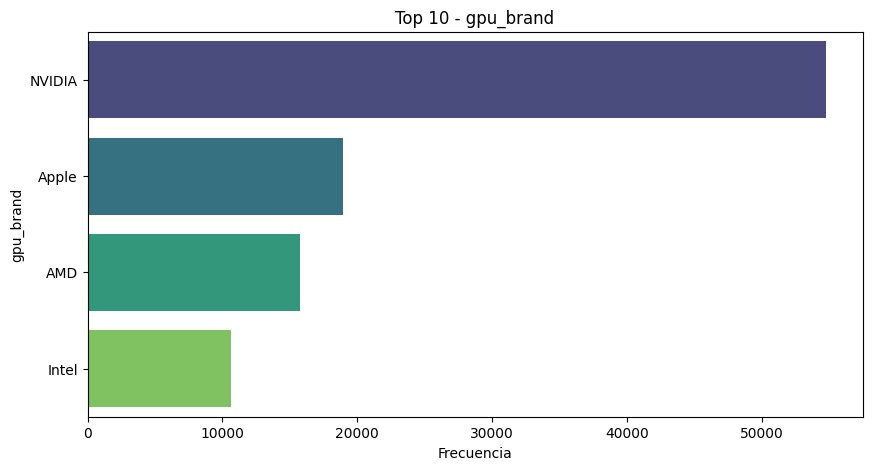

/tmp/ipykernel_1998/1143160511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


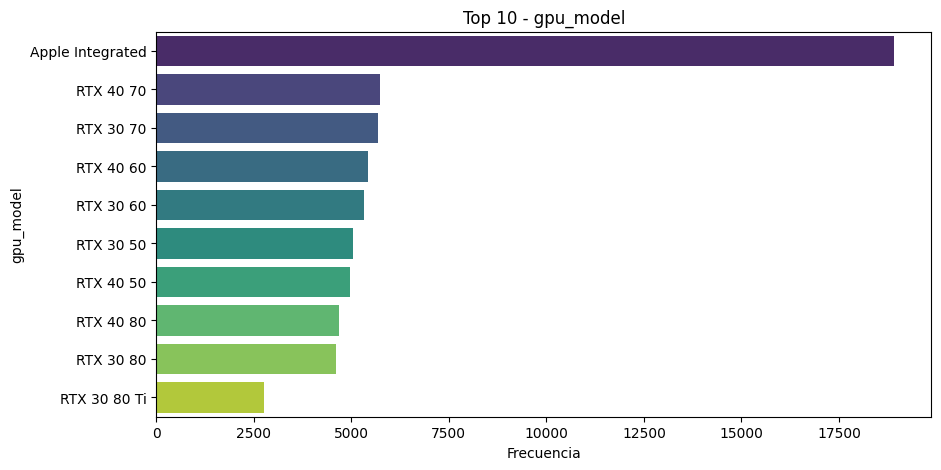

/tmp/ipykernel_1998/1143160511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


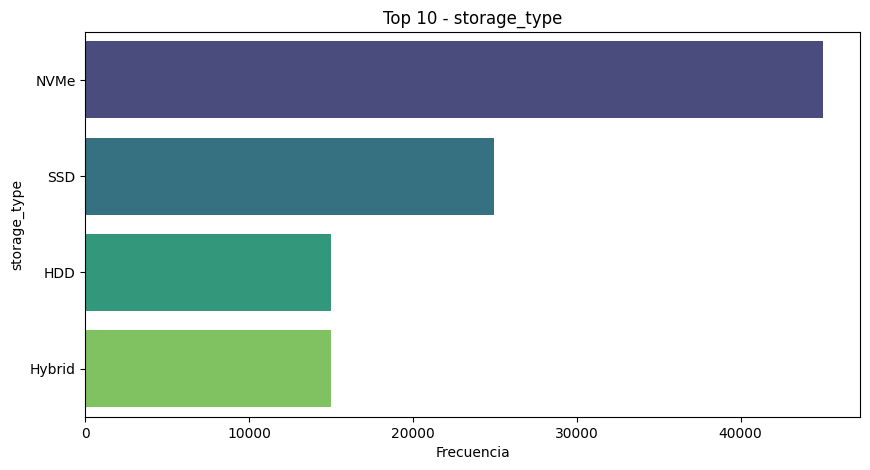

/tmp/ipykernel_1998/1143160511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


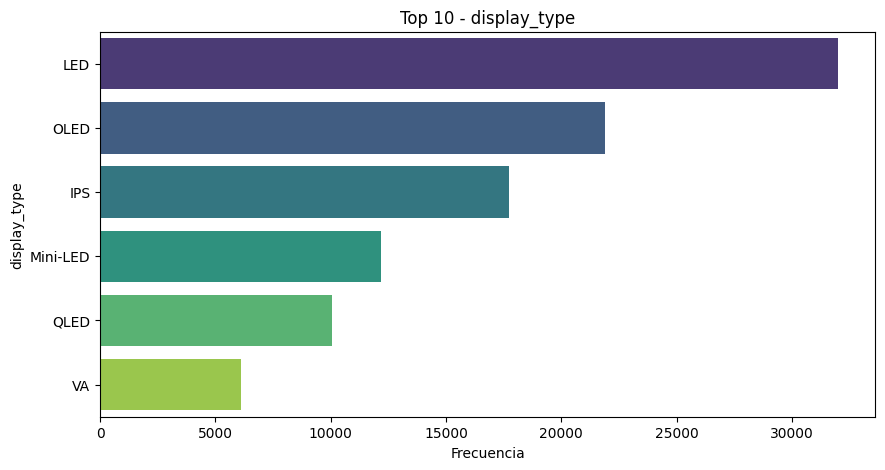

/tmp/ipykernel_1998/1143160511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


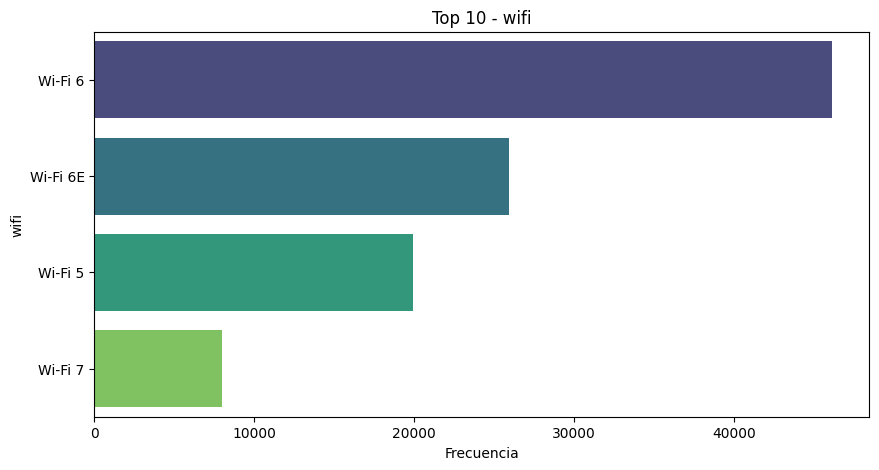

In [ ]:
# Diagrama de barras para variables categóricas (los 10 más frecuentes)
for col in columnas_categoricas:
    plt.figure(figsize=(10, 5))
    top_10 = compu_df[col].value_counts().head(10)
    sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')
    plt.title(f'Top 10 - {col}')
    plt.xlabel('Frecuencia')
    plt.ylabel(col)
    plt.show()

3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables, de las que se imprimieron, representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

In [ ]:
# Cálculo de la matriz de correlación
columnas_numericas = compu_df.select_dtypes(include=['int64', 'float64']).columns
matriz_corr = compu_df[columnas_numericas].corr()

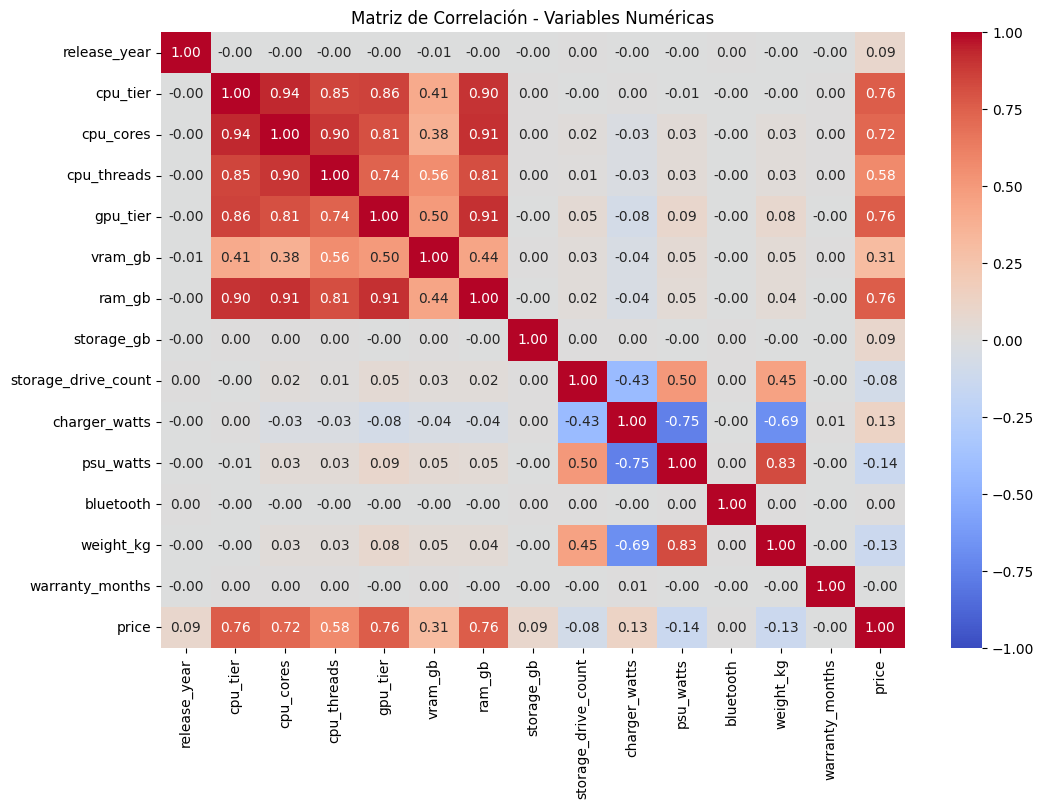

In [ ]:
# Mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

In [ ]:
#Identificar pares de variables con correlación > 0.9
pares_alta_corr = []
for i in range(len(matriz_corr.columns)):
    for j in range(i):
        if abs(matriz_corr.iloc[i, j]) > 0.9:
            variable1 = matriz_corr.columns[i]
            variable2 = matriz_corr.columns[j]
            coeficiente = matriz_corr.iloc[i, j]
            pares_alta_corr.append((variable1, variable2, coeficiente))

print("\nPares de variables con correlación > 0.9:")
for var1, var2, coef in pares_alta_corr:
    print(f"- {var1} y {var2} (Correlación: {coef:.2f})")


Pares de variables con correlación > 0.9:
- cpu_cores y cpu_tier (Correlación: 0.94)
- ram_gb y cpu_cores (Correlación: 0.91)
- ram_gb y gpu_tier (Correlación: 0.91)


In [ ]:
# ── 3. Eliminar variables redundantes ────────────────────────────────────────
cols_to_drop = ["cpu_threads", "ram_gb"]
compu_df.drop(columns=cols_to_drop, inplace=True)

print(f"\nColumnas eliminadas : {cols_to_drop}")
print(f"Shape final         : {compu_df.shape}")


Columnas eliminadas : ['cpu_threads', 'ram_gb']
Shape final         : (100000, 23)


Decisión: variables a conservar y eliminar
Triángulo CPU: cpu_tier — cpu_cores — ram_gb
Los tres forman un grupo altamente correlacionado. La elección es la siguiene de acuerdo a su conceptualización:

Variables a conservar:
Conservar cpu_tier — Es una escala ordinal (1–6) que resume directamente la jerarquía de rendimiento del procesador. Es la variable más compacta y general del grupo.
Conservar cpu_cores — Aunque correlaciona con cpu_tier, representa una medida física concreta (número de núcleos) con valor propio en modelos de precio, ya que el mercado diferencia explícitamente entre 4, 8, 16 y 28 cores.

Variables a eliminar:
Eliminar cpu_threads — Es casi un múltiplo exacto de cpu_cores (r = 0.90 con cpu_cores, r = 0.85 con cpu_tier). En la práctica, los threads = cores × 2 en la mayoría de arquitecturas modernas (Hyper-Threading / SMT), por lo que no agrega información independiente.
Eliminar ram_gb — Aunque la RAM es un componente importante, en este dataset su variación está casi completamente determinada por cpu_tier y gpu_tier (r ≈ 0.90–0.91). La capacidad del hardware queda mejor representada por las variables de tier, que tienen semántica directa de gama.

4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_transf`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un gráfico de barras para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

In [ ]:
# ── 1. Crear copia ─
compu_transf = compu_df.copy()

In [ ]:
# ── 2. Aplicar cálculo del año en nueva variable ─
compu_transf = compu_df.copy()
current_year = 2026
compu_transf["years_since_release"] = current_year - compu_transf["release_year"]
compu_transf.drop(columns=["release_year"], inplace=True, errors='ignore')

In [ ]:
compu_transf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   os                   100000 non-null  object 
 3   form_factor          100000 non-null  object 
 4   cpu_brand            100000 non-null  object 
 5   cpu_tier             100000 non-null  int64  
 6   cpu_cores            100000 non-null  int64  
 7   gpu_brand            100000 non-null  object 
 8   gpu_model            100000 non-null  object 
 9   gpu_tier             100000 non-null  int64  
 10  vram_gb              100000 non-null  int64  
 11  storage_type         100000 non-null  object 
 12  storage_gb           100000 non-null  int64  
 13  storage_drive_count  100000 non-null  int64  
 14  display_type         100000 non-null  object 
 15  charger_watts     

In [ ]:
# ── 3. Aplicar KBinsDiscretizer sobre variable vram_gb (4 bins ordinales, cuantiles)─────────────────────────────────────────
kbd = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile")
compu_transf["vram_gb"] = kbd.fit_transform(compu_transf[["vram_gb"]]).astype(int)

In [ ]:
# Imprimir los valores que delimitan cada bin. Para acceder a los bordes calculados por el quantil
edges = kbd.bin_edges_[0]
print("Límites de bins (GB) para vram_gb (Cuantiles):", edges)
for i in range(len(edges) - 1):
    print(f"  Bin {i}  →  [{int(edges[i])} GB  –  {int(edges[i+1])} GB)")

Límites de bins (GB) para vram_gb (Cuantiles): [ 0.  4.  6.  8. 16.]
  Bin 0  →  [0 GB  –  4 GB)
  Bin 1  →  [4 GB  –  6 GB)
  Bin 2  →  [6 GB  –  8 GB)
  Bin 3  →  [8 GB  –  16 GB)


In [ ]:
# Conteo por bin
print("\nObservaciones por bin:")
print(compu_transf["vram_gb"].value_counts().sort_index())


Observaciones por bin:
vram_gb
0    20757
1    20517
2    17930
3    40796
Name: count, dtype: int64


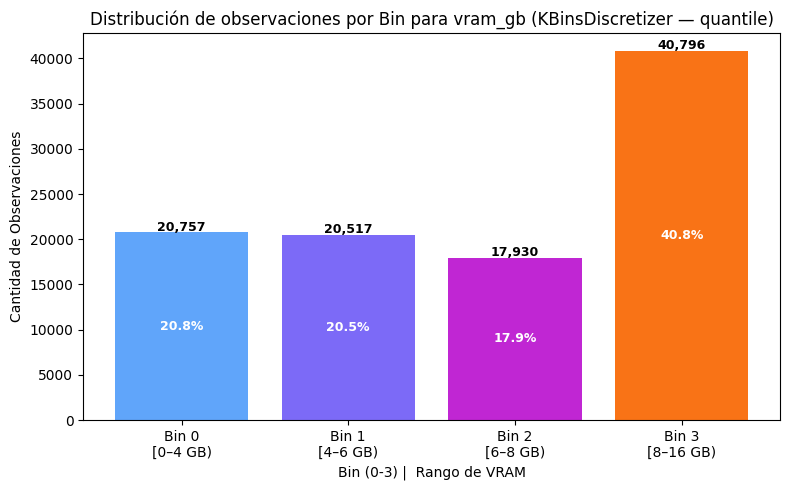

In [ ]:
# ── 4. Generaión de Gráfico de Barras ──────────────────────────────────────────────────────
labels = [f"Bin {i}\n[{int(edges[i])}–{int(edges[i+1])} GB)" for i in range(4)]
counts = compu_transf["vram_gb"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts.values, color=["#60a5fa","#7c6af7","#c026d3","#f97316"])

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}", ha="center", fontsize=9, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f"{val/len(compu_transf)*100:.1f}%", ha="center",
            va="center", color="white", fontsize=9, fontweight="bold")

ax.set_title("Distribución de observaciones por Bin para vram_gb (KBinsDiscretizer — quantile)")
ax.set_xlabel("Bin (0-3) |  Rango de VRAM")
ax.set_ylabel("Cantidad de Observaciones")
plt.tight_layout()
plt.savefig("vram_bins.png", bbox_inches="tight")
plt.show()


Razonamiento de los cambios:
Transformar el campo release_year en years_since_release convierte una fecha absoluta en una medida relativa al año presente (2026). Esto proporciona más información para un modelo. Ya que no importa que sea del año 2022, sino que tiene 4 años de antigüedad, lo que impacta directamente en el precio y la depreciación del producto.

Con relación a la obtención de los Bines. El Bin 3 agrupa el 40.8% de los registros, el valor más alto que el resto. Esto ocurre porque vram_gb tiene valores discretos (0, 2, 4, 6, 8, 10, 12, 16 GB), no una distribución continua. Cuando los cuantiles calculados caen en medio de un valor repetido, KBinsDiscretizer no puede dividirlo y asigna todos esos registros al mismo bin. En este caso, el umbral teórico del cuartil 75 cae en 8 GB, pero dado que hay una masa importante de observaciones con exactamente 8, 10, 12 y 16 GB, todas se consolidan en el último bin. Es un comportamiento esperado y correcto cuando la variable de entrada es discreta y asimétrica; la variable resultante sigue siendo ordinal y útil para el modelado.

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

In [ ]:
# ── 1. Observación: cruce con device_type ─────────────────────────────────────
print(pd.crosstab(compu_transf["device_type"],
      (compu_transf["charger_watts"]==0).map({True:"charger=0",False:"charger>0"})))

print(pd.crosstab(compu_transf["device_type"],
      (compu_transf["psu_watts"]==0).map({True:"psu=0",False:"psu>0"})))


charger_watts  charger=0  charger>0
device_type                        
Desktop            40156          0
Laptop                 0      59844
psu_watts    psu=0  psu>0
device_type              
Desktop          0  40156
Laptop       59844      0


In [ ]:
# Confirmar exclusividad mutua
both_zero = ((compu_transf["charger_watts"]==0) & (compu_transf["psu_watts"]==0)).sum()
print(f"Registros con ambas columnas = 0: {both_zero}")   # → 0

Registros con ambas columnas = 0: 0


In [ ]:
# ── 2. Combinar en power_watts ────────────────────────────────────────────────
compu_transf["power_watts"] = compu_transf["charger_watts"] + compu_transf["psu_watts"]

In [ ]:
# ── 3. Eliminar columnas ────────────────────────────────────────────────
compu_transf.drop(columns=["charger_watts","psu_watts"], inplace=True)

In [ ]:
print(compu_transf["power_watts"].describe())

count    100000.000000
mean        333.903950
std         310.304358
min          45.000000
25%          90.000000
50%         120.000000
75%         650.000000
max        1200.000000
Name: power_watts, dtype: float64


In [ ]:
compu_transf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   os                   100000 non-null  object 
 3   form_factor          100000 non-null  object 
 4   cpu_brand            100000 non-null  object 
 5   cpu_tier             100000 non-null  int64  
 6   cpu_cores            100000 non-null  int64  
 7   gpu_brand            100000 non-null  object 
 8   gpu_model            100000 non-null  object 
 9   gpu_tier             100000 non-null  int64  
 10  vram_gb              100000 non-null  int64  
 11  storage_type         100000 non-null  object 
 12  storage_gb           100000 non-null  int64  
 13  storage_drive_count  100000 non-null  int64  
 14  display_type         100000 non-null  object 
 15  wifi              

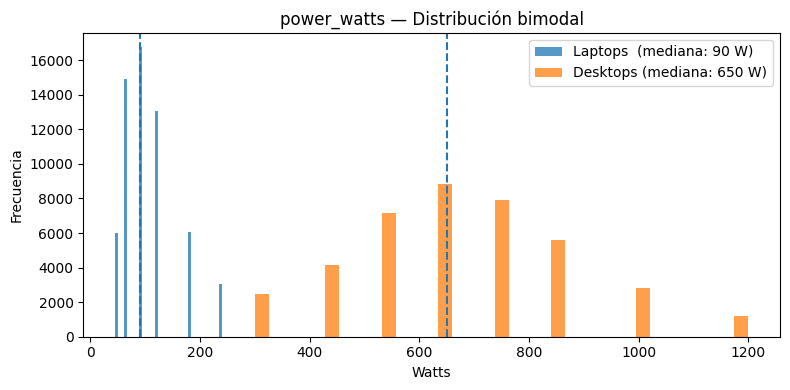

In [ ]:
# ── 3. Histograma bimodal ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

laptops  = compu_transf.loc[compu_df["device_type"]=="Laptop",  "power_watts"]
desktops = compu_transf.loc[compu_df["device_type"]=="Desktop", "power_watts"]

ax.hist(laptops,  bins=35, alpha=0.75, label=f"Laptops  (mediana: {laptops.median():.0f} W)")
ax.hist(desktops, bins=35, alpha=0.75, label=f"Desktops (mediana: {desktops.median():.0f} W)")
ax.axvline(laptops.median(),  linestyle="--", linewidth=1.5)
ax.axvline(desktops.median(), linestyle="--", linewidth=1.5)

ax.set_title("power_watts — Distribución bimodal")
ax.set_xlabel("Watts"); ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.savefig("power_watts.png", bbox_inches="tight")
plt.show()


*Observa los histogramas del ejercicio 2. Notarás que en las variables charger_watts y psu_watts aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.*
De acuerdo con la descripción de cada variable significa conceptos físicos no compatibles según el tipo de dispositivo:

charger_watts registra la potencia del adaptador de corriente de una laptop. Un desktop no tiene cargador externo, así que su valor es 0: no es un dato faltante, es que el concepto no aplica.
psu_watts registra la potencia de la fuente de alimentación interna de un desktop. Una laptop tampoco tiene PSU interna, así que su valor es igualmente 0.

La barra en 0 que se veía en los histogramas del ejercicio 2 no es un error de captura; es porque esa variable no tiene sentido.

6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

In [ ]:
# ── 1. Transformaciones temporales ────────────────────────────────────────────
price = compu_transf["price"]
bc_arr, lam = stats.boxcox(price + 1)    # +1 por precaución (price > 0 aquí)

transforms = {
    "Original":        price,
    "Log":             np.log1p(price),
    "Raíz Cuadrada":   np.sqrt(price),
    "Box-Cox":         pd.Series(bc_arr),
}

In [ ]:
# ── 2. Métricas: skew y outliers (IQR) ───────────────────────────────────────
def outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())

for name, s in transforms.items():
    print(f"{name:18s}  skew={s.skew():.4f}  outliers={outlier_count(s)}")

print(f"\nLambda Box-Cox: {lam:.4f}")

Original            skew=0.9866  outliers=976
Log                 skew=-0.1326  outliers=387
Raíz Cuadrada       skew=0.3323  outliers=364
Box-Cox             skew=-0.0002  outliers=317

Lambda Box-Cox: 0.1499


/tmp/ipykernel_1998/4241079397.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


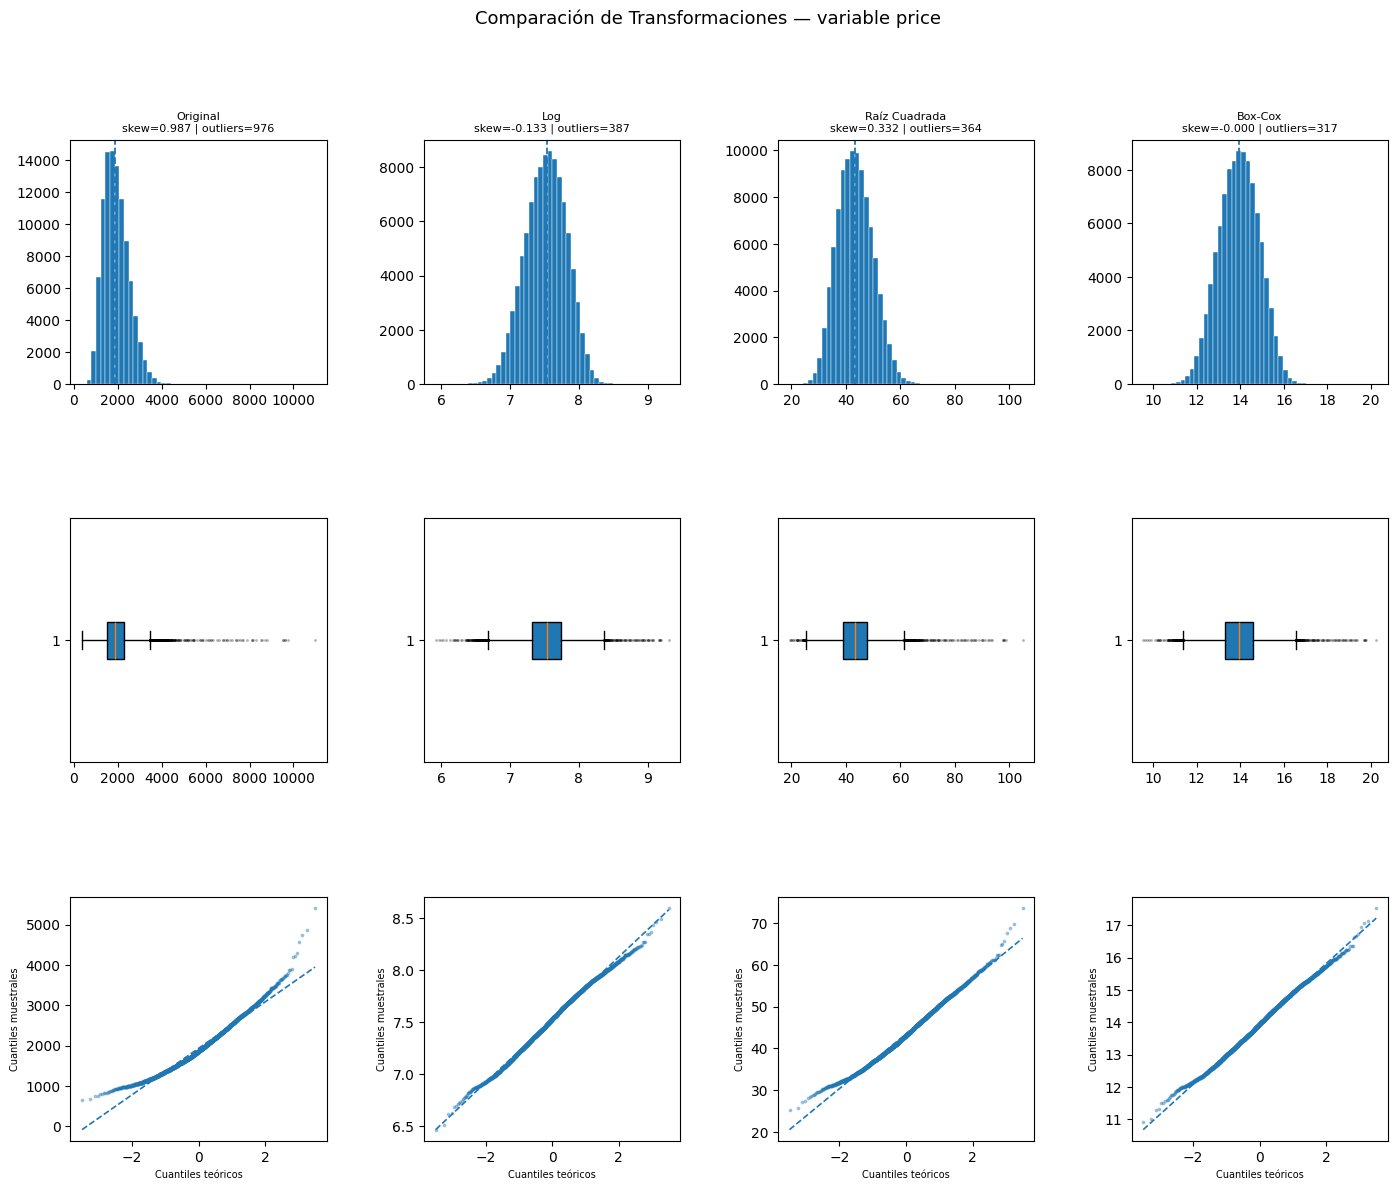

In [ ]:
import matplotlib.gridspec as gridspec

# ── 3. Visualización (Histograma | Boxplot | Q-Q) × 4 transformaciones ────────
fig = plt.figure(figsize=(17, 13))
fig.suptitle("Comparación de Transformaciones — variable price", fontsize=13)
outer = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)

for col_i, (name, s) in enumerate(transforms.items()):
    s = s.reset_index(drop=True)

    # Histograma
    ax0 = fig.add_subplot(outer[0, col_i])
    ax0.hist(s, bins=50, edgecolor="white", linewidth=0.3)
    ax0.axvline(s.median(), linestyle="--", linewidth=1.3)
    ax0.set_title(f"{name}\nskew={s.skew():.3f} | outliers={outlier_count(s)}", fontsize=8)

    # Boxplot
    ax1 = fig.add_subplot(outer[1, col_i])
    ax1.boxplot(s, vert=False, patch_artist=True,
                flierprops=dict(marker=".", markersize=2, alpha=0.3))

    # Q-Q plot
    ax2 = fig.add_subplot(outer[2, col_i])
    sample = s.sample(3000, random_state=42)
    (osm, osr), (slope, intercept, _) = stats.probplot(sample, dist="norm")
    ax2.scatter(osm, osr, s=3, alpha=0.35)
    ax2.plot([osm.min(), osm.max()],
             [slope*osm.min()+intercept, slope*osm.max()+intercept],
             linestyle="--", linewidth=1.2)
    ax2.set_xlabel("Cuantiles teóricos", fontsize=7)
    ax2.set_ylabel("Cuantiles muestrales", fontsize=7)

plt.tight_layout()
plt.savefig("price_transformaciones.png", bbox_inches="tight")
plt.show()

Box-Cox (λ = 0.15)
Es la transformación ganadora en los tres criterios:

Skew ≈ 0.0002 — prácticamente cero, la distribución más simétrica de las cuatro.
317 outliers — la menor cantidad, lo que indica que los valores extremos quedaron mejor absorbidos.
Q-Q plot — los puntos se adhieren a la diagonal a lo largo de casi todo el rango, con desviaciones mínimas solo en los extremos más lejanos.

In [ ]:
# ── 4. Se aplicará Box-Cox a las variables continuas ──────────────────────────────
for col in ["weight_kg", "power_watts", "price"]:
    compu_transf[col], _ = stats.boxcox(compu_transf[col] + 1)

print("\nTransformación Box-Cox aplicada a: weight_kg, power_watts, price")
print(compu_transf[["weight_kg","power_watts","price"]].describe().round(4))


Transformación Box-Cox aplicada a: weight_kg, power_watts, price
         weight_kg  power_watts        price
count  100000.0000  100000.0000  100000.0000
mean        0.8062       3.4682      13.9500
std         0.1900       0.4111       0.9233
min         0.5084       2.8157       9.5436
25%         0.6497       3.1521      13.3076
50%         0.7313       3.2815      13.9605
75%         1.0140       3.9302      14.6040
max         1.1215       4.1240      20.2446


7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [ ]:
# ── 1. Identificar columnas numéricas ────────────────────────────────────────────
num_cols = compu_transf.select_dtypes(include="number").columns.tolist()
print(f"Columnas a escalar ({len(num_cols)}): {num_cols}")


Columnas a escalar (12): ['cpu_tier', 'cpu_cores', 'gpu_tier', 'vram_gb', 'storage_gb', 'storage_drive_count', 'bluetooth', 'weight_kg', 'warranty_months', 'price', 'years_since_release', 'power_watts']


In [ ]:
# ── 2. Estadísticas ANTES ────────────────────────────────────────────────────────
print("\nAntes del escalado:")
print(compu_transf[num_cols].describe().T[["min", "max", "mean", "std"]].round(4))


Antes del escalado:
                          min        max      mean       std
cpu_tier               1.0000     6.0000    3.1535    1.3732
cpu_cores              4.0000    28.0000   10.5157    5.0441
gpu_tier               1.0000     6.0000    2.9914    1.4596
vram_gb                0.0000     3.0000    1.7876    1.1825
storage_gb           256.0000  4096.0000  903.9360  774.2437
storage_drive_count    1.0000     4.0000    1.5250    0.7973
bluetooth              4.2000     5.3000    5.0848    0.2460
weight_kg              0.5084     1.1215    0.8062    0.1900
warranty_months       12.0000    48.0000   22.2004   10.2319
price                  9.5436    20.2446   13.9500    0.9233
years_since_release    1.0000     8.0000    3.6792    2.0258
power_watts            2.8157     4.1240    3.4682    0.4111


In [ ]:
# ── 3. Aplicar MinMaxScaler ──────────────────────────────────────────────────────
scaler = MinMaxScaler()
compu_transf[num_cols] = scaler.fit_transform(compu_transf[num_cols])


In [ ]:
# ── 4. Verificación DESPUÉS de aplicar MinMaxScaler──────────────────────────────────────────────────────
print("\nDespués del escalado (min=0.0 / max=1.0 en todas las variables numéricas):")
print(compu_transf[num_cols].agg(["min", "max"]).round(6))


Después del escalado (min=0.0 / max=1.0 en todas las variables numéricas):
     cpu_tier  cpu_cores  gpu_tier  vram_gb  storage_gb  storage_drive_count  \
min       0.0        0.0       0.0      0.0         0.0                  0.0   
max       1.0        1.0       1.0      1.0         1.0                  1.0   

     bluetooth  weight_kg  warranty_months  price  years_since_release  \
min        0.0        0.0              0.0    0.0                  0.0   
max        1.0        1.0              1.0    1.0                  1.0   

     power_watts  
min          0.0  
max          1.0  


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [ ]:
# ── 1. Verificar categorías antes de codificar ────────────────────────────────
print("Categorías únicas:", compu_transf["wifi"].unique())
print(compu_transf["wifi"].value_counts())

Categorías únicas: ['Wi-Fi 6' 'Wi-Fi 5' 'Wi-Fi 6E' 'Wi-Fi 7']
wifi
Wi-Fi 6     46149
Wi-Fi 6E    25923
Wi-Fi 5     19926
Wi-Fi 7      8002
Name: count, dtype: int64


In [ ]:
# ── 2. OrdinalEncoder con orden explícito ─────────────────────────────────────
wifi_order = [["Wi-Fi 5", "Wi-Fi 6", "Wi-Fi 6E", "Wi-Fi 7"]]

oe = OrdinalEncoder(categories=wifi_order, dtype=float)
compu_transf["wifi"] = oe.fit_transform(compu_transf[["wifi"]])
# → Wi-Fi 5=0, Wi-Fi 6=1, Wi-Fi 6E=2, Wi-Fi 7=3

In [ ]:
# ── 3. MinMaxScaler para llevar a rango [0, 1] ────────────────────────────────
mms = MinMaxScaler()
compu_transf["wifi"] = mms.fit_transform(compu_transf[["wifi"]])
# → Wi-Fi 5=0.0, Wi-Fi 6=0.333, Wi-Fi 6E=0.667, Wi-Fi 7=1.0

In [ ]:
# ── Tabla de mapeo completo ───────────────────────────────────────────────────
mapping = pd.DataFrame({
    "Categoría": wifi_order[0],
    "Ordinal":   [0, 1, 2, 3],
    "Escalado":  [0.0, 1/3, 2/3, 1.0]
})
print(mapping)

  Categoría  Ordinal  Escalado
0   Wi-Fi 5        0  0.000000
1   Wi-Fi 6        1  0.333333
2  Wi-Fi 6E        2  0.666667
3   Wi-Fi 7        3  1.000000


In [ ]:
# Verificación final
print("\nValores únicos finales:", sorted(compu_transf["wifi"].unique()))
print("dtype:", compu_transf["wifi"].dtype)


Valores únicos finales: [np.float64(0.0), np.float64(0.3333333333333333), np.float64(0.6666666666666666), np.float64(1.0)]
dtype: float64


wifi no es una variable nominal (sin orden) sino ordinal con orden tecnológico claro: cada generación supera a la anterior en velocidad, latencia y capacidad. Usar OneHotEncoder ignoraría esa jerarquía y crearía 4 columnas binarias independientes, perdiendo la información de progresión. OrdinalEncoder convierte esa jerarquía en una secuencia numérica 0→1→2→3 que preserva la relación de orden.

9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [ ]:
# ── Aplicar BinaryEncoder sobre la variable gpu_model ────────────────────────────────────────────
print(f"Categorías únicas en gpu_model: {compu_transf['gpu_model'].nunique()}")
print(f"Columnas que generaría OHE:     {compu_transf['gpu_model'].nunique()}")
print(f"Bits necesarios (⌈log₂(49)⌉):  {int(np.ceil(np.log2(49)))}")

encoder = BinaryEncoder(cols=["gpu_model"], drop_invariant=True)
bin_df  = encoder.fit_transform(compu_transf[["gpu_model"]])

print(f"\nColumnas generadas por BinaryEncoder: {bin_df.shape[1]}")
print(f"Columnas de bin_df: {bin_df.columns.tolist()}")
print(f"\nShape final de bin_df: {bin_df.shape}")
print(bin_df.head(8))

Categorías únicas en gpu_model: 49
Columnas que generaría OHE:     49
Bits necesarios (⌈log₂(49)⌉):  6

Columnas generadas por BinaryEncoder: 6
Columnas de bin_df: ['gpu_model_0', 'gpu_model_1', 'gpu_model_2', 'gpu_model_3', 'gpu_model_4', 'gpu_model_5']

Shape final de bin_df: (100000, 6)
   gpu_model_0  gpu_model_1  gpu_model_2  gpu_model_3  gpu_model_4  \
0            0            0            0            0            0   
1            0            0            0            0            1   
2            0            0            0            0            1   
3            0            0            0            1            0   
4            0            0            0            1            0   
5            0            0            0            1            1   
6            0            0            0            1            1   
7            0            0            0            1            1   

   gpu_model_5  
0            1  
1            0  
2            1  
3         

10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [ ]:
# ── 1. OneHotEncoder sobre las categóricas restantes ─────────────────────────
ohe_cols = ["device_type","brand","os","form_factor",
            "cpu_brand","gpu_brand","storage_type","display_type"]

ohe = OneHotEncoder(drop="first", sparse_output=False, dtype=float)
ohe_arr = ohe.fit_transform(compu_transf[ohe_cols])
ohe_df  = pd.DataFrame(ohe_arr,
                        columns=ohe.get_feature_names_out(ohe_cols),
                        index=compu_transf.index)

print(f"ohe_df shape: {ohe_df.shape}")
print(f"Columnas generadas:\n{ohe_df.columns.tolist()}")


ohe_df shape: (100000, 35)
Columnas generadas:
['device_type_Laptop', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_Lenovo', 'brand_MSI', 'brand_Razer', 'brand_Samsung', 'os_Linux', 'os_Windows', 'os_macOS', 'form_factor_ATX', 'form_factor_Full-Tower', 'form_factor_Gaming', 'form_factor_Mainstream', 'form_factor_Micro-ATX', 'form_factor_Mini-ITX', 'form_factor_SFF', 'form_factor_Ultrabook', 'form_factor_Workstation', 'cpu_brand_Apple', 'cpu_brand_Intel', 'gpu_brand_Apple', 'gpu_brand_Intel', 'gpu_brand_NVIDIA', 'storage_type_Hybrid', 'storage_type_NVMe', 'storage_type_SSD', 'display_type_LED', 'display_type_Mini-LED', 'display_type_OLED', 'display_type_QLED', 'display_type_VA']


In [ ]:
# ── 2. Combinar los tres dataframes ──────────────────────────────────────────
cols_to_drop = ohe_cols + ["gpu_model"]

compu_final = pd.concat([
    compu_transf.drop(columns=cols_to_drop),  # numéricas + wifi
    bin_df,                                    # gpu_model codificada (6 cols)
    ohe_df                                     # resto categóricas (35 cols)
], axis=1)

print(f"\ncompu_final shape: {compu_final.shape}")



compu_final shape: (100000, 54)


In [ ]:
# ── 3. Verificación con describe() ───────────────────────────────────────────
desc = compu_final.describe().T[["min", "max", "mean"]]
print(desc.to_string())

                         min  max      mean
cpu_tier                 0.0  1.0  0.430698
cpu_cores                0.0  1.0  0.271489
gpu_tier                 0.0  1.0  0.398270
vram_gb                  0.0  1.0  0.595883
storage_gb               0.0  1.0  0.168733
storage_drive_count      0.0  1.0  0.174993
wifi                     0.0  1.0  0.406670
bluetooth                0.0  1.0  0.804331
weight_kg                0.0  1.0  0.485814
warranty_months          0.0  1.0  0.283343
price                    0.0  1.0  0.411778
years_since_release      0.0  1.0  0.382736
power_watts              0.0  1.0  0.498785
gpu_model_0              0.0  1.0  0.118160
gpu_model_1              0.0  1.0  0.224950
gpu_model_2              0.0  1.0  0.381060
gpu_model_3              0.0  1.0  0.482690
gpu_model_4              0.0  1.0  0.525590
gpu_model_5              0.0  1.0  0.686920
device_type_Laptop       0.0  1.0  0.598440
brand_Acer               0.0  1.0  0.099250
brand_Apple              0.0  1.

In [ ]:
# Verificación programática
cat_restantes = compu_final.select_dtypes(include="object").columns.tolist()
fuera_rango   = desc[(desc["min"] < -0.001) | (desc["max"] > 1.001)].index.tolist()

print(f"\n Variables categóricas sin codificar : {len(cat_restantes)}")
print(f" Columnas fuera del rango [0, 1]    : {len(fuera_rango)}")
print(f" Total de columnas finales           : {compu_final.shape[1]}")


 Variables categóricas sin codificar : 0
 Columnas fuera del rango [0, 1]    : 0
 Total de columnas finales           : 54


Con los resultados finales se comprueba que las categorias restates se condificaron en 0 y 1 aplicando OneHorEncoder.

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

* Antropic (2026) Claude (Sonnet 4.6 [Modelo de lenguaje grande],
utilizado para generación de código]. https://claude.ai/

* Google (2026) Gemini [Modelo de lenguaje grande], utilizado para corrección de código. https://gemini.google.com/